In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [21]:
file_path = "../data/Pharma_data_analysis.xlsx"
df = pd.read_excel(file_path)
print(f"Dataset shape: {df.shape}")

Dataset shape: (254082, 18)


In [22]:
df.head()

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Åšwiecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,CzeladÅº,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018,Anne Wu,Britanny Bold,Delta


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 254082 entries, 0 to 254081
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Distributor        254082 non-null  str    
 1   Customer Name      254082 non-null  str    
 2   City               254082 non-null  str    
 3   Country            254082 non-null  str    
 4   Latitude           254082 non-null  float64
 5   Longitude          254082 non-null  float64
 6   Channel            254082 non-null  str    
 7   Sub-channel        254082 non-null  str    
 8   Product Name       254082 non-null  str    
 9   Product Class      254082 non-null  str    
 10  Quantity           254082 non-null  float64
 11  Price              254082 non-null  int64  
 12  Sales              254082 non-null  float64
 13  Month              254082 non-null  str    
 14  Year               254082 non-null  int64  
 15  Name of Sales Rep  254082 non-null  str    
 16  Manager      

In [24]:
df.isnull().sum()

Distributor          0
Customer Name        0
City                 0
Country              0
Latitude             0
Longitude            0
Channel              0
Sub-channel          0
Product Name         0
Product Class        0
Quantity             0
Price                0
Sales                0
Month                0
Year                 0
Name of Sales Rep    0
Manager              0
Sales Team           0
dtype: int64

In [26]:
df.describe()

,Latitude,Longitude,Quantity,Price,Sales,Year
count,254082.000000,254082.000000,254082.000000,254082.000000,2.540820e+05,254082.000000
mean,50.962222,10.803212,112.872139,412.207720,4.643772e+04,2018.385187
std,1.625526,4.143311,744.310385,224.963687,3.491918e+05,1.041352
min,47.514200,6.083800,-7200.000000,22.000000,-4.161600e+06,2017.000000
25%,49.805600,7.891100,5.000000,195.000000,1.704000e+03,2018.000000
50%,51.133300,9.397800,20.000000,430.000000,5.850000e+03,2018.000000
75%,52.083300,12.133300,50.000000,605.000000,2.156525e+04,2019.000000
max,54.781900,23.566700,117600.000000,794.000000,7.420560e+07,2020.000000


In [27]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nUnique values per categorical column:")
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head())

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18848\651370217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns



Unique values per categorical column:

Distributor: 29 unique values
Distributor
Gerlach LLC         111364
Koss                 58360
Erdman               26238
Stehr-Champlin       11942
Smith Inc             6802
Name: count, dtype: int64

Customer Name: 751 unique values
Customer Name
Spinka, Schowalter and Conn                 440
Fritsch, Hodkiewicz and Sipes Pharma Plc    437
Weber Ltd Pharmaceutical Ltd                436
Corkery-Kovacek Pharm                       436
Nolan, DuBuque and Schultz                  434
Name: count, dtype: int64

City: 749 unique values
City
Friedberg    796
Neustadt     760
Bergheim     440
Ettlingen    437
Merseburg    436
Name: count, dtype: int64

Country: 2 unique values
Country
Germany    213598
Poland      40484
Name: count, dtype: int64

Channel: 2 unique values
Channel
Pharmacy    129971
Hospital    124111
Name: count, dtype: int64

Sub-channel: 4 unique values
Sub-channel
Retail         68351
Government     65605
Institution    61620
Pri

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18848\381072668.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_sales.values, y=channel_sales.index, palette='viridis')


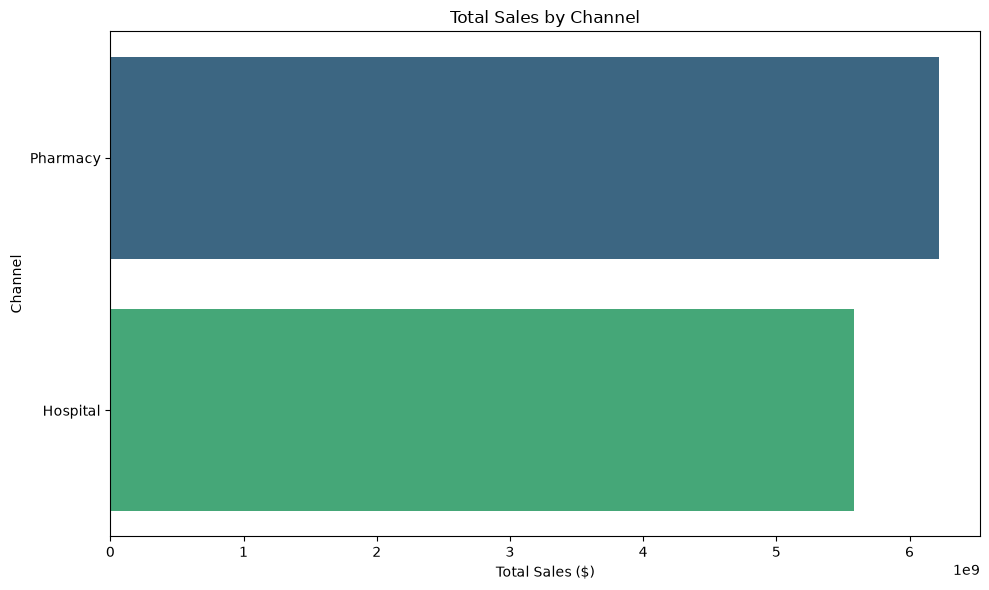

In [29]:
plt.figure(figsize=(10,6))
channel_sales = df.groupby('Channel')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=channel_sales.values, y=channel_sales.index, palette='viridis')
plt.title('Total Sales by Channel')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig("../images/sales_by_channel.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18848\1531780897.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.values, y=city_sales.index, palette='rocket')


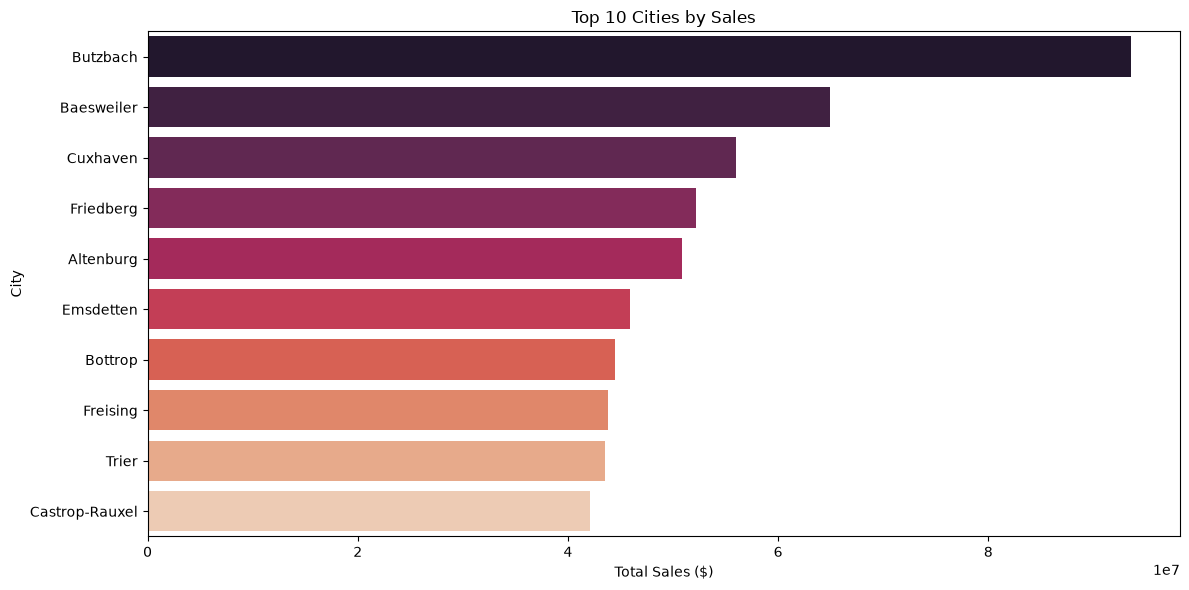

In [30]:
plt.figure(figsize=(12,6))
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=city_sales.values, y=city_sales.index, palette='rocket')
plt.title('Top 10 Cities by Sales')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig("../images/top_cities.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18848\2678259370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_sales.values, y=product_sales.index, palette='magma')


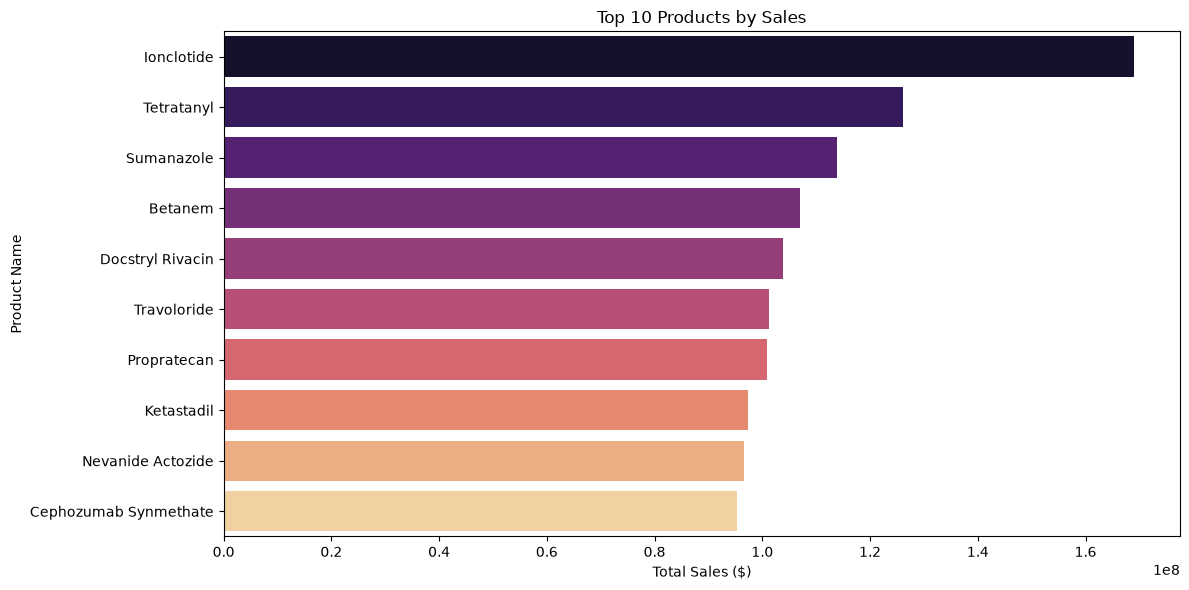

In [31]:
plt.figure(figsize=(12,6))
product_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=product_sales.values, y=product_sales.index, palette='magma')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig("../images/top_products.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18848\1476472182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_sales.values, y=class_sales.index, palette='coolwarm')


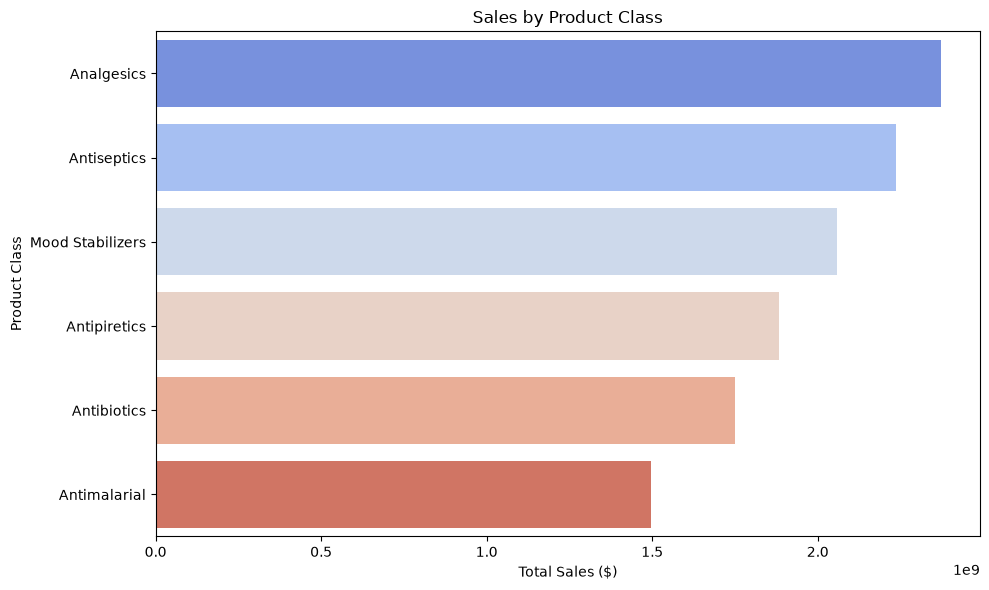

In [32]:
plt.figure(figsize=(10,6))
class_sales = df.groupby('Product Class')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=class_sales.values, y=class_sales.index, palette='coolwarm')
plt.title('Sales by Product Class')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig("../images/sales_by_class.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18848\1906722763.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_sales.values, y=team_sales.index, palette='Spectral')


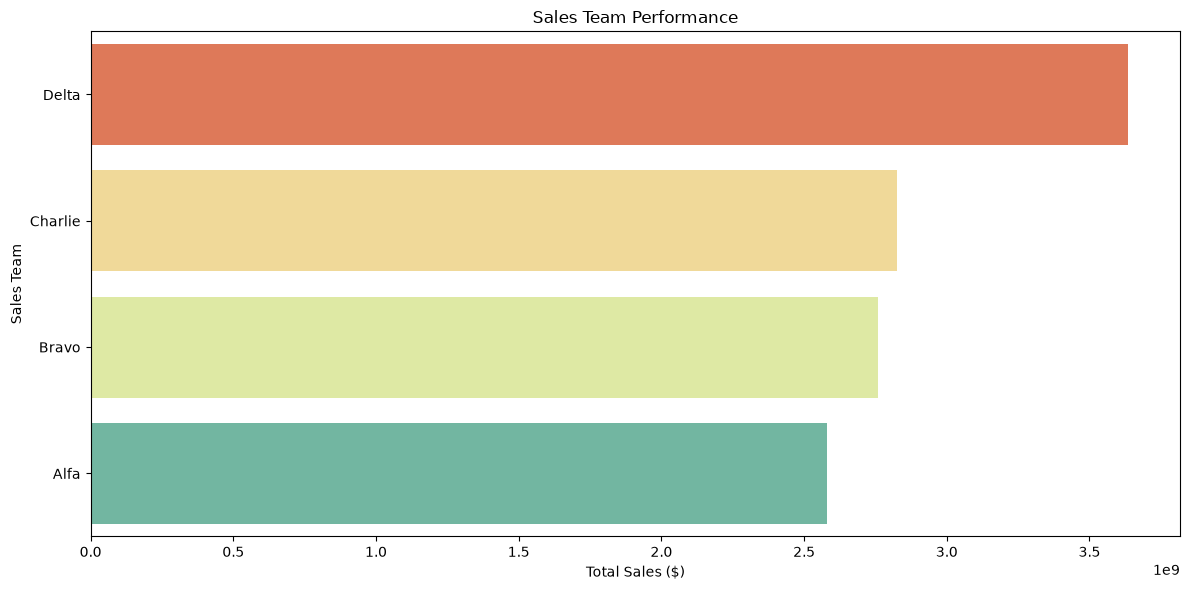

In [33]:
plt.figure(figsize=(12,6))
team_sales = df.groupby('Sales Team')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=team_sales.values, y=team_sales.index, palette='Spectral')
plt.title('Sales Team Performance')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig("../images/team_performance.png", dpi=150, bbox_inches='tight')
plt.show()

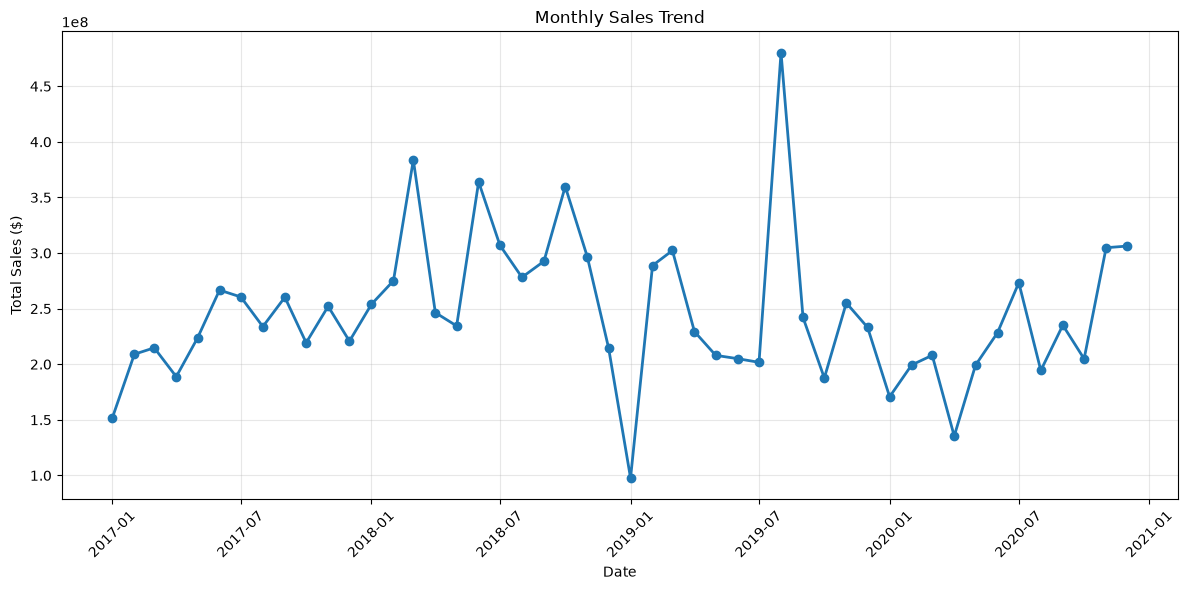

In [34]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
monthly_sales = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/monthly_trend.png", dpi=150, bbox_inches='tight')
plt.show()